In [57]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib 


In [58]:
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0 # Add label
df_tritrig = df_tritrig.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0 # Add label
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label
df_wab = df_wab.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

df_data_train_bkg = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_limited_sideband_train_bkg.pk')
df_data_train_bkg['PhiKK'] = 0.0 # Add label

df_data = pd.read_pickle('/Users/mghrear/data/ML_data/patch/BDT_2019_data_limited_sideband_test.pk')

print("phiKK: ", len(df_phiKK))
print("data bkg: ", len(df_data_train_bkg))
print("data: ", len(df_data))

phiKK:  8164
data bkg:  23704
data:  43926


In [59]:
# Make Training set
phiKK_train = df_phiKK[0:4000]


# Combine and shuffle all training data
df_train = pd.concat([phiKK_train, df_data_train_bkg], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

X_train = df_train.drop(columns=['PhiKK'])
Y_train = df_train['PhiKK']

# Make testing set
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[4000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[4000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
Y_test = df_test['PhiKK']

# Make data set
X_final = df_data




/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_21151/1017004853.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_21151/1017004853.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_21151/1017004853.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [60]:
print("tritrig: ", len(tritrig_test))
print("phiKK: ", len(phiKK_test))
print("wab: ", len(wab_test))


tritrig:  233375
phiKK:  4164
wab:  12365


In [61]:
# Use AdaBoostClassifier with DecisionTreeClassifier as the base model
base_tree = DecisionTreeClassifier(random_state=0)
#model = AdaBoostClassifier(base_estimator = DTC)
clf = AdaBoostClassifier(estimator=base_tree)

In [62]:
X_train

,ele_E_Ecal,pos_E_Ecal,ele_Ecal_x,ele_Ecal_y,ele_Ecal_z,pos_Ecal_x,pos_Ecal_y,pos_Ecal_z,ele_Px,ele_Py,ele_Pz,pos_Px,pos_Py,pos_Pz
0,0.000000,0.334848,-9999.000000,-9999.000000,-9999.000000,294.272339,60.905388,1450.481689,0.060921,-0.036298,2.446082,0.094843,0.049791,1.408306
1,1.716865,2.350057,-174.733246,-44.290005,1449.943115,196.352982,28.060823,1449.394531,-0.053000,-0.057172,1.959465,0.082634,0.041082,2.013943
2,0.000000,2.748442,-9999.000000,-9999.000000,-9999.000000,165.384872,28.040140,1449.173706,-0.005159,-0.043622,0.831272,0.103515,0.049424,2.649867
3,0.000000,1.364397,-9999.000000,-9999.000000,-9999.000000,283.327484,-31.237806,1450.047485,0.079422,0.055447,2.761056,0.011806,-0.024943,1.077200
4,1.180141,1.483112,-168.769424,-35.152363,1449.943115,142.058014,28.129047,1448.951538,0.040720,-0.033984,1.380945,0.079833,0.041617,2.868228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27699,1.145035,0.691503,-258.744293,-27.827766,1450.472046,263.186462,36.437618,1450.051147,0.006471,-0.020877,1.166394,0.028000,0.030774,1.241884
27700,0.000000,0.697739,-9999.000000,-9999.000000,-9999.000000,350.471527,30.443670,1450.576660,0.032787,-0.014574,0.681399,0.045148,0.021875,1.046535
27701,0.000000,1.645398,-9999.000000,-9999.000000,-9999.000000,210.713715,47.867805,1449.616211,0.065200,-0.055665,1.546966,0.086067,0.048983,2.031638
27702,1.195935,0.909245,-215.431625,31.648651,1450.154541,341.863098,-37.706947,1450.582764,0.036597,0.023179,1.047243,0.019197,-0.026309,1.012734


In [63]:
# Use GridSearchCV to optimize hyper parameters
# The parameter search can be increased as desired, I do a pretty small search
param_grid = {"estimator__criterion" : ["gini"],
              "estimator__splitter" : ["best"],
              "estimator__max_depth": [2,3],
              "n_estimators": [50,75]
             }


grid_search_ABC = GridSearchCV(clf, param_grid=param_grid, scoring = 'roc_auc', n_jobs=-1,cv=3)

grid_search_ABC.fit(X_train, Y_train)

Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzL2Z4L2N6cmtsdHc5NTN4Y3BjamQ4NXRmMnRtbTAwMDBnbi9UL2pvYmxpYl9tZW1tYXBwaW5nX2ZvbGRlcl8yMTE1MV8xODI5YmU1N2Y4YmU0ODVmYjczYzAxMWZiNzBhNjZlN180ZWRiNzY1ZGQ4NTk0YTA2YWNjM2VmYWYzZDViMGQzMA=="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "REGISTER","rtype":"folder","base64_name" for automatic cleanup: unknown resource type ("L3Zhci9mb2xkZXJzL2Z4L2N6cmtsdHc5NTN4Y3BjamQ4N

,estimator,AdaBoostClass...ndom_state=0))
,param_grid,"{'estimator__criterion': ['gini'], 'estimator__max_depth': [2, 3], 'estimator__splitter': ['best'], 'n_estimators': [50, 75]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [64]:
print(" Results from Grid Search " )
print("\n The best estimator across ALL searched params:\n",grid_search_ABC.best_estimator_)
print("\n The best score across ALL searched params:\n",grid_search_ABC.best_score_)
print("\n The best parameters across ALL searched params:\n",grid_search_ABC.best_params_)

 Results from Grid Search 

 The best estimator across ALL searched params:
 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=0),
                   n_estimators=75)

 The best score across ALL searched params:
 0.9984719930699227

 The best parameters across ALL searched params:
 {'estimator__criterion': 'gini', 'estimator__max_depth': 3, 'estimator__splitter': 'best', 'n_estimators': 75}


Test model accuracy: 0.9929!
Test AUROC: 0.9972


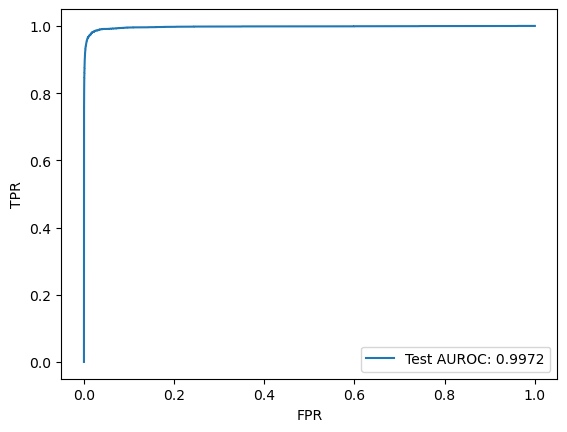

In [65]:
# Use the optimized model to evaluate performance on the held out validation set.
accuracy_test = np.mean(grid_search_ABC.best_estimator_.predict(X_test) == Y_test)
print(f'Test model accuracy: {accuracy_test:0.4f}!')

Yhat_test = grid_search_ABC.best_estimator_.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = sklearn.metrics.roc_curve(Y_test, Yhat_test, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()


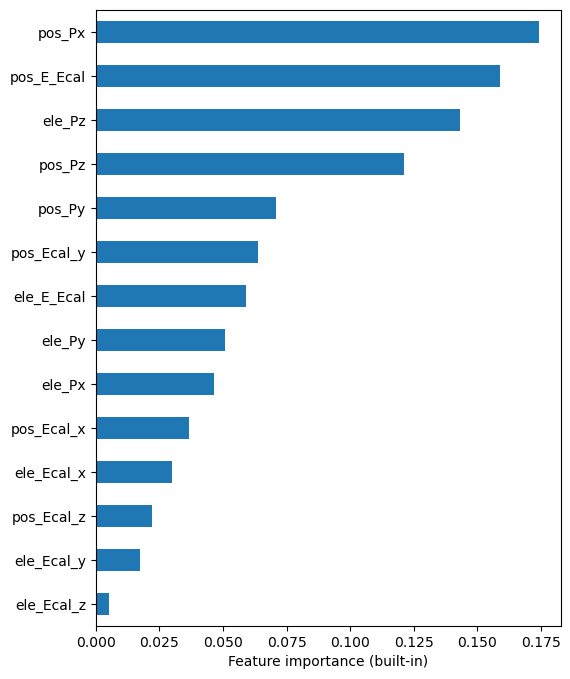

In [66]:
best = grid_search_ABC.best_estimator_
feat_names = X_train.columns
importances = best.feature_importances_
imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)
imp_series.head(30).plot(kind='barh', figsize=(6,8))
plt.gca().invert_yaxis()
plt.xlabel('Feature importance (built-in)')
plt.show()


In [67]:
# Collect all test info into a dataframe
df_test['Yhat'] = Yhat_test


# Calculate invariant mass and add to dataframe
m_K = 0.493677
# Calculate total electron momentum
df_test['e_Ptot'] = np.sqrt(df_test['ele_Px']**2 + df_test['ele_Py']**2 + df_test['ele_Pz']**2)
# Calculate total positron momentum
df_test['p_Ptot'] = np.sqrt(df_test['pos_Px']**2 + df_test['pos_Py']**2 + df_test['pos_Pz']**2)
df_test['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df_test.e_Ptot**2 / (df_test.e_Ptot**2  + m_K**2) ) )
df_test['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df_test.p_Ptot**2 / (df_test.p_Ptot**2  + m_K**2) ) )
df_test['M'] = np.sqrt((df_test.e_SVT_E_K+df_test.p_SVT_E_K)**2 - (df_test.ele_Px+df_test.pos_Px)**2 - (df_test.ele_Py+df_test.pos_Py)**2 - (df_test.ele_Pz+df_test.pos_Pz)**2)

In [68]:
df_test.to_pickle("/Users/mghrear/data/ML_data/patch/BDT_results_limited_sideband_a.pk")
joblib.dump(grid_search_ABC.best_estimator_, '/Users/mghrear/data/ML_data/patch/BDT_2019_limited_sideband_a_model.pkl')

['/Users/mghrear/data/ML_data/patch/BDT_2019_limited_sideband_a_model.pkl']

In [69]:
# Split into tritrig and phiKK dataframes
test_df_tritrig = df_test[df_test['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = df_test[df_test['type']=="phiKK"].reset_index(drop=True)
test_df_wab = df_test[df_test['type']=="wab"].reset_index(drop=True)


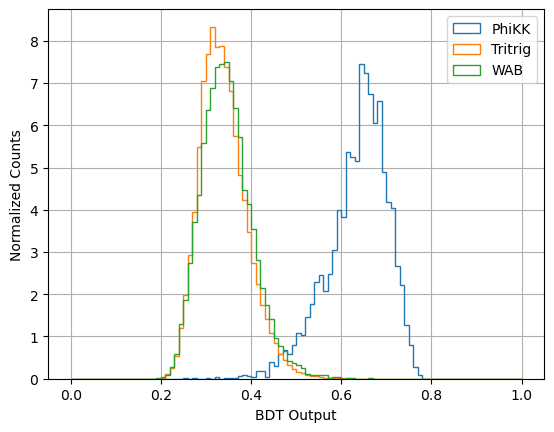

Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "UNREGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktMjExNTEtdDVwOXdsamw="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch/lib/python3.14/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 297, in main
    raise ValueError(
    ...<4 lines>...
    )
ValueError: Cannot register "UNREGISTER","rtype":"semlock","base64_name" for automatic cleanup: unknown resource type ("L2xva3ktMjExNTEtN3JxZWdydHo="}). Resource type should be one of the following: ['noop', 'folder', 'file', 'semlock']
Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch/lib/python3.14/site

In [70]:
test_df_phiKK.Yhat.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='PhiKK',density=True)
test_df_tritrig.Yhat.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='Tritrig',density=True)
test_df_wab.Yhat.hist(bins=np.arange(0,1.01,0.01), histtype='step', label='WAB',density=True)
#plt.axvline(x=0.4, color='k', linestyle='--', label ="selection line")
plt.xlabel('BDT Output')
plt.ylabel('Normalized Counts')
plt.legend()